This notebook contains the reanalysis of the Mellors et al. singe Cell RNA seq dataset ( JCI insight GSE29034) shown in Figure 4 B-E and Supplementary Figure S5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sb
import bbknn
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


plt.rcParams['pdf.fonttype'] = 42

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.1, on 2026-04-02 13:47.


# Load data Object 

In [2]:
object_folder = "/media/HDD_1/sc_data_objects/BOS/"
adata = sc.read(object_folder + "GSE29034_merged_seurat_objects_1.h5ad")


In [3]:
plot_folder = "/media/synology/Rahel/BOS paper/plots5/"
sc.settings.figdir = plot_folder
sc.set_figure_params(vector_friendly = True)

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams.update({'font.size': 14})
plt.rcParams['pdf.fonttype'] = 42
plt.tight_layout()
sb.set_style("ticks")
plt.rcParams['pdf.fonttype'] = 42
sc.set_figure_params(adata, vector_friendly=True, format='pdf', dpi_save=300, facecolor=None, transparent=False, ipython_format='png2x')
plt.tight_layout()



<Figure size 480x400 with 0 Axes>

In [4]:
adata

AnnData object with n_obs × n_vars = 149764 × 30081
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log10genesperUMI', 'percent.mt', 'percent.rb', 'cells', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'pANN_0.25_0.01_479', 'DF', 'predicted.lineage_level1.score', 'predicted.lineage_level1', 'predicted.lineage_level2.score', 'predicted.lineage_level2', 'predicted.celltype_level1.score', 'predicted.celltype_level1', 'predicted.celltype_level2.score', 'predicted.celltype_level2', 'predicted.celltype_level3.score', 'predicted.celltype_level3', 'pANN_0.25_0.03_275', 'pANN_0.25_0.005_288', 'pANN_0.25_0.25_422', 'pANN_0.25_0.04_522', 'pANN_0.25_0.005_270', 'pANN_0.25_0.03_373', 'pANN_0.25_0.04_565', 'integrated_snn_res.0.4', 'integrated_snn_res.0.6', 'integrated_snn_res.0.8', 'integrated_snn_res.1', 'integrated_snn_res.1.4', 'nCount_prediction.score.lineage_level1', 'nFeature_prediction.score.lineage_level1', 'nCount_prediction.score.lineage_level2', 'nFeature_pred

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:16)


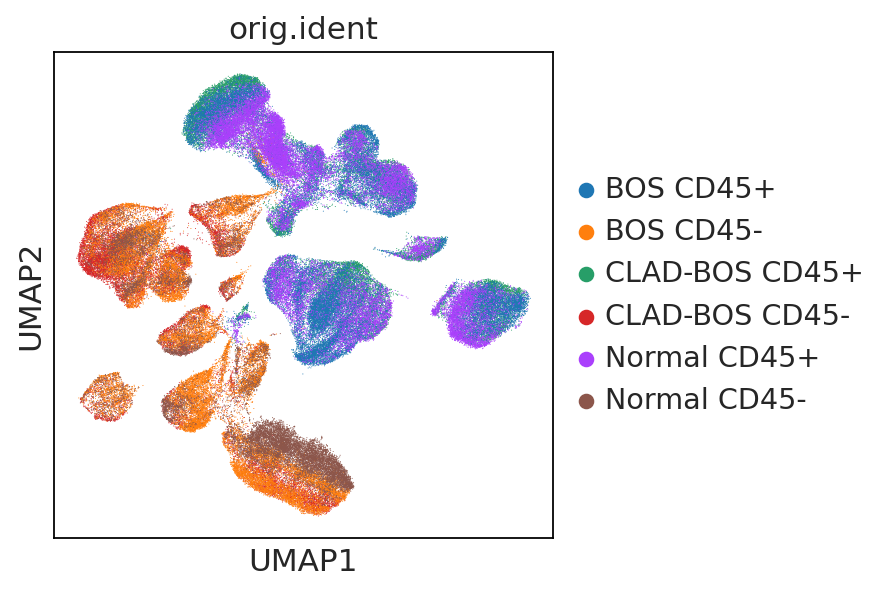

In [5]:
import bbknn
bbknn.bbknn(adata, neighbors_within_batch = 5, n_pcs = 50, batch_key = "orig.ident")
sc.tl.umap(adata)
sc.pl.umap(adata, color = ["orig.ident"], wspace = 0.2)

In [6]:
ct_map = {"BOS CD45+":'BOS',
"BOS CD45-":'BOS',
'CLAD-BOS CD45+': 'CLAD-BOS',
'CLAD-BOS CD45-': 'CLAD-BOS',
'Normal CD45+':"Control",
'Normal CD45-':"Control",}
adata.obs["condition"] = [ct_map[ct] for ct in adata.obs["orig.ident"]]

In [7]:
ct_map = {"BOS CD45+":'BOS',
"BOS CD45-":'BOS',
'CLAD-BOS CD45+': 'BOS',
'CLAD-BOS CD45-': 'BOS',
'Normal CD45+':"Control",
'Normal CD45-':"Control",}
adata.obs["condition2"] = [ct_map[ct] for ct in adata.obs["orig.ident"]]

# Cell type harmonization with 4i

In [8]:
exclude_values = ['Mesothelial']
adata = adata[~adata.obs['annotation'].isin(exclude_values)].copy()

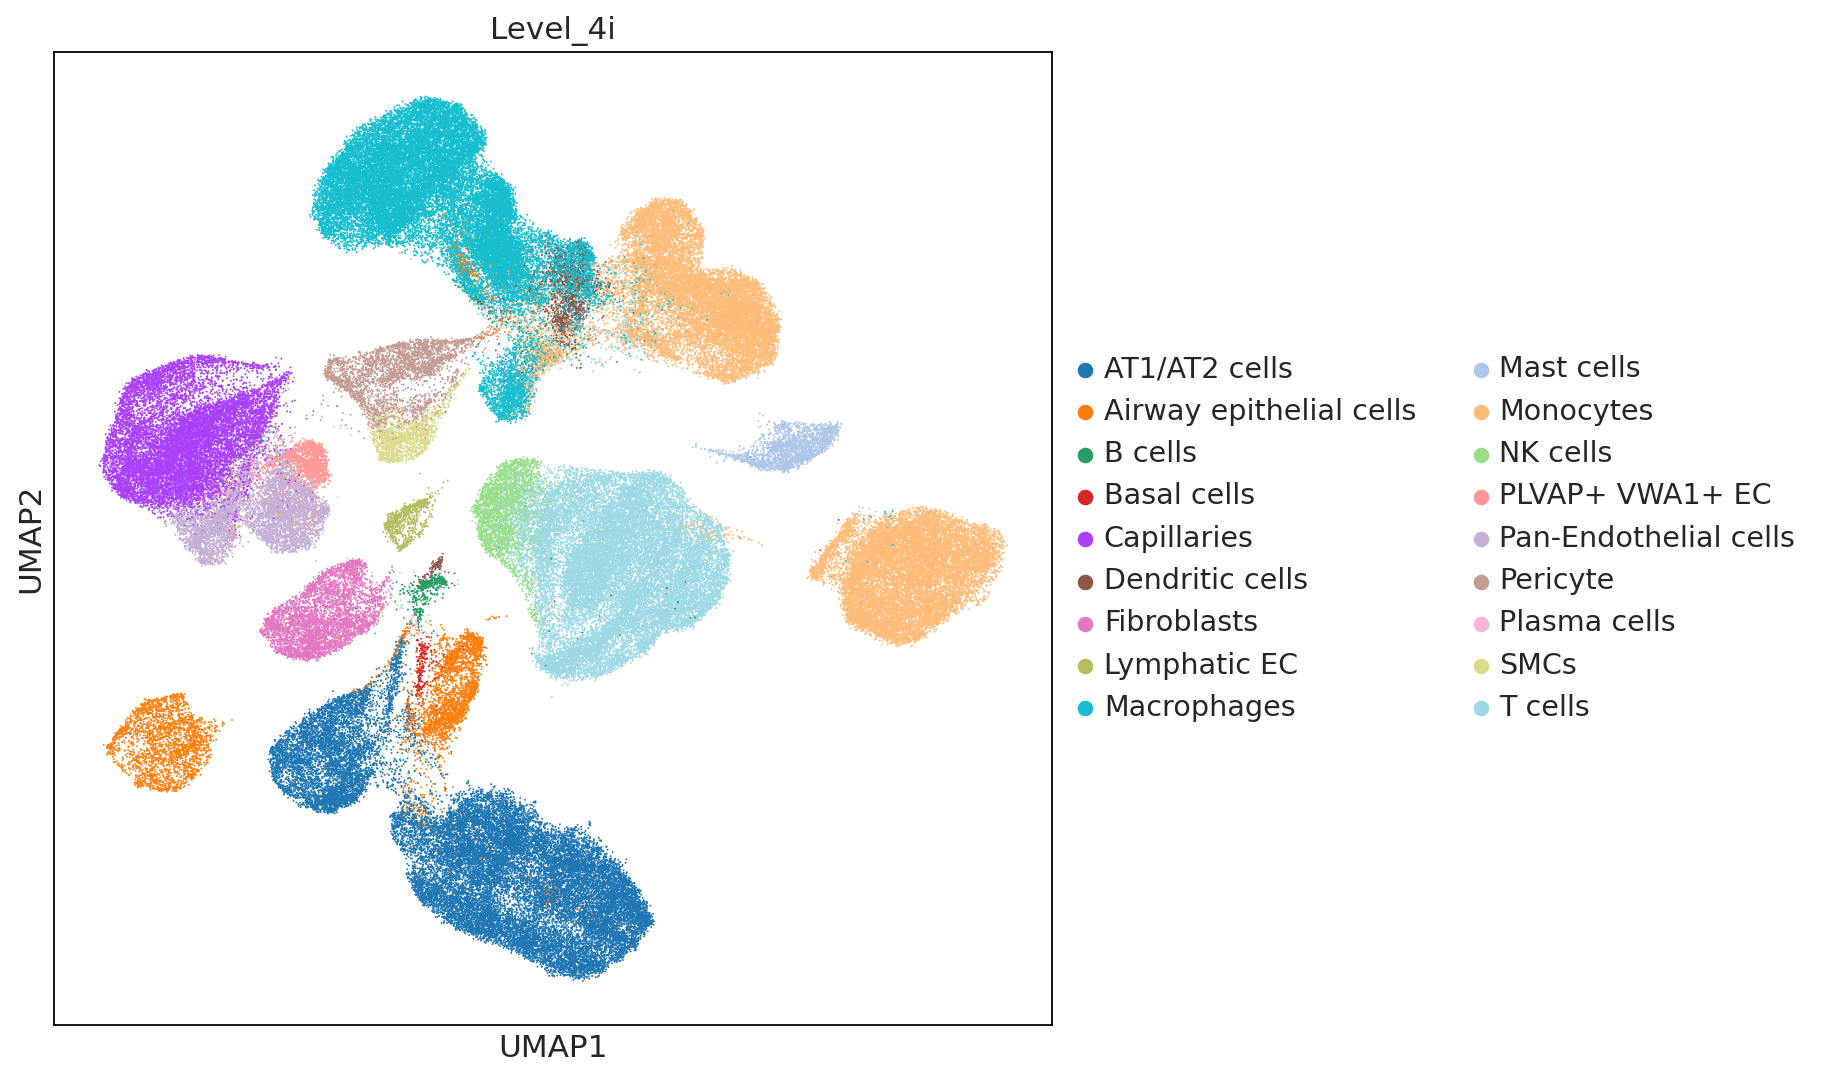

In [9]:
ct_map = {

 'AT2': 'AT1/AT2 cells',
 'AT1':'AT1/AT2 cells',
 'CAP1' :'Capillaries',
 'Ciliated':'Airway epithelial cells',
 'AF1':'Fibroblasts',
 'CAP2':'Capillaries',
 'SCMF':'Fibroblasts',#secondary crest myofibroblasts
 'AF2':'Fibroblasts',
 'LEC':'Lymphatic EC',
 'Pericyte':'Pericyte',
 'RAS':'Airway epithelial cells',
 'VSMC':'SMCs',
 'VEC':'Pan-Endothelial cells',
 'SVEC':'PLVAP+ VWA1+ EC',
 'Secretory':'Airway epithelial cells',
 'AEC':'Pan-Endothelial cells',
 'ASMC':'SMCs',
 'Goblet':'Airway epithelial cells',
 'Basal/Suprabasal':'Basal cells',
 'Serous':'Airway epithelial cells',
 'SMG_Basal/Duct':'Airway epithelial cells',
 'Ionocyte':'Airway epithelial cells',
 'Tuft':'Airway epithelial cells',
 'PNEC':'Airway epithelial cells',
 'Non-classical monocytes':'Monocytes',
 'DC2':'Dendritic cells',
 'NK cells':'NK cells',
 'Classical monocytes':'Monocytes',
 'Plasmacytoid DCs':'Dendritic cells',
 'Alveolar macrophages':'Macrophages',
 'B cells':'B cells',
 'CD8 T cells':'T cells',
 'CD4 T cells':'T cells',
 'Interstitial Mφ perivascular':'Macrophages',
 'Mast cells':'Mast cells',
 'Monocyte-derived Mφ':'Macrophages',
 'Plasma cells':'Plasma cells',
 'T cells proliferating':'T cells',
 'Alveolar Mφ proliferating':'Macrophages',
 'Migratory DCs':'Dendritic cells',
 'Alveolar Mφ CCL3+':'Macrophages'
}

 

adata.obs["Level_4i"] = [ct_map[ct] for ct in adata.obs.annotation]

 

fig, ax = plt.subplots(figsize=(8, 8))

sc.pl.umap(adata, color = ["Level_4i"], ax=ax, size = 3)   # 23

In [10]:
order2=[ 'Airway epithelial cells',
    'AT1/AT2 cells',
    'B cells',
    'Basal cells',
    'Capillaries',
    'Dendritic cells',
    'Fibroblasts',
    'Lymphatic EC',
    'Macrophages',
    'Mast cells',
    'Monocytes',
    'NK cells',
    'PLVAP+ VWA1+ EC',
    'Pan-Endothelial cells',
    'Pericyte',
    'Plasma cells',
    'SMCs',
    'T cells',
    ]

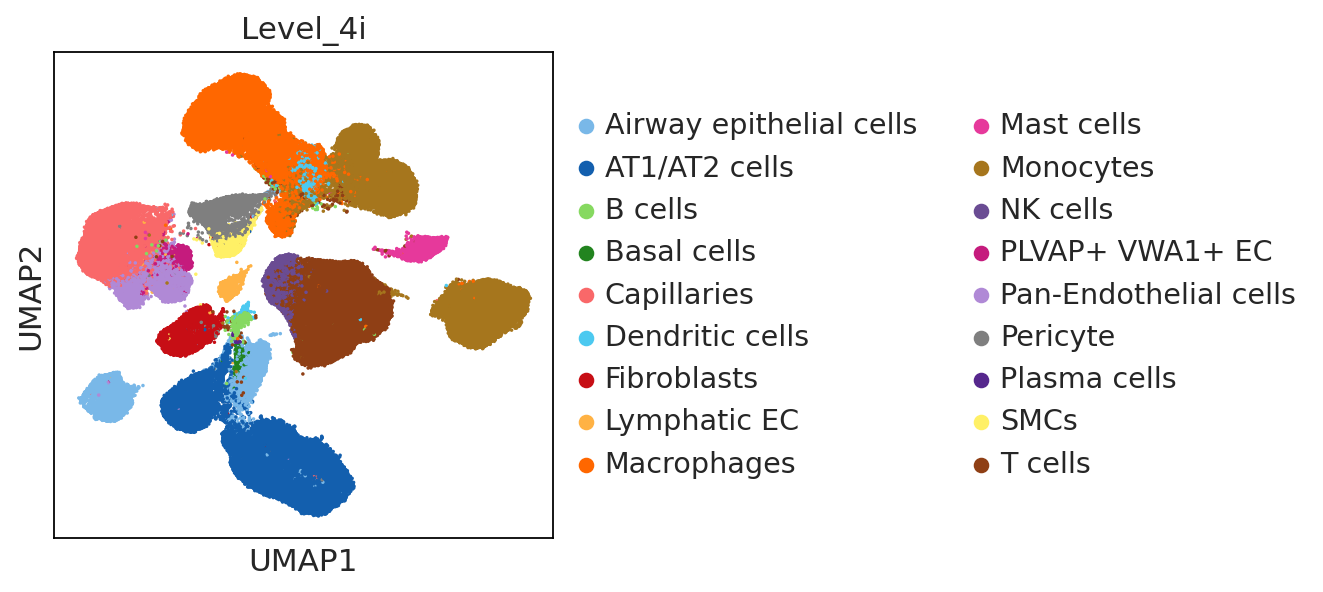

In [11]:
new_cols3={
'Airway epithelial cells': '#79b8e8',
    'AT1/AT2 cells': '#135fae',
    'B cells': '#86d960',
    'Basal cells': '#22841f',
    'Capillaries': '#f96869',
    'Dendritic cells': '#4cc9f0',
    'Fibroblasts': '#c70e15',
    'Lymphatic EC': '#ffb244',
    'Macrophages': '#ff6700',
    'Mast cells': '#e6399b',
    'Monocytes': '#a6761d',
    'NK cells': '#6a4c93',
    'PLVAP+ VWA1+ EC': '#c51b7d',
    'Pan-Endothelial cells': '#b089d6',
    'Pericyte': '#7f7f7f',
    'Plasma cells': '#56278d',
    'SMCs': '#fff066',
    'T cells': '#8f3f15',
   
}

label1 = "Level_4i"
cols3 = [new_cols3[ct] for ct in order2]

adata.obs['Level_4i'] = adata.obs['Level_4i'].cat.reorder_categories(order2)
adata.uns["%s_colors" %label1] = cols3
sc.pl.umap(adata, color = ["Level_4i"], size = 10)

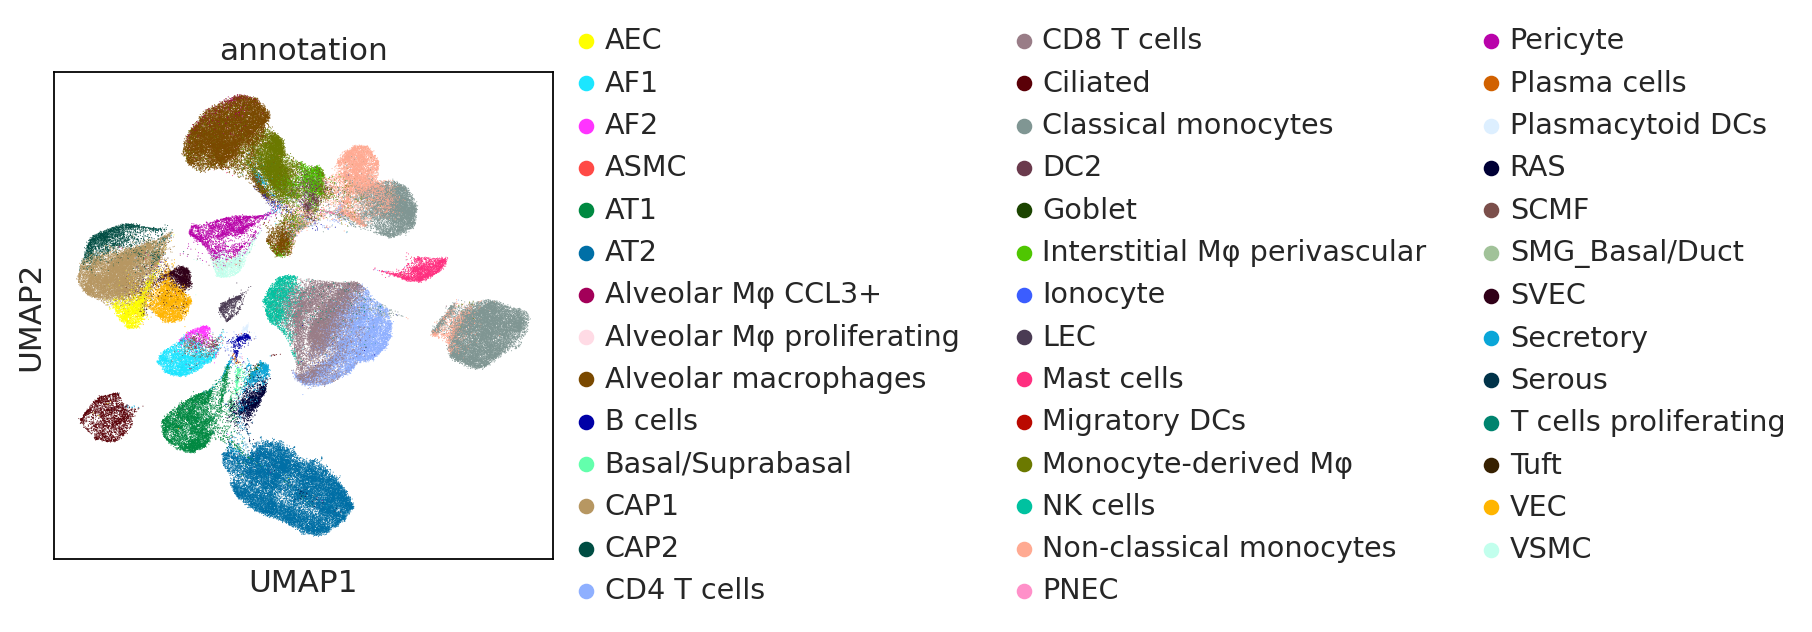

In [12]:
sc.pl.umap(adata, color = ["annotation"],save=("_Public_celltype.pdf"))

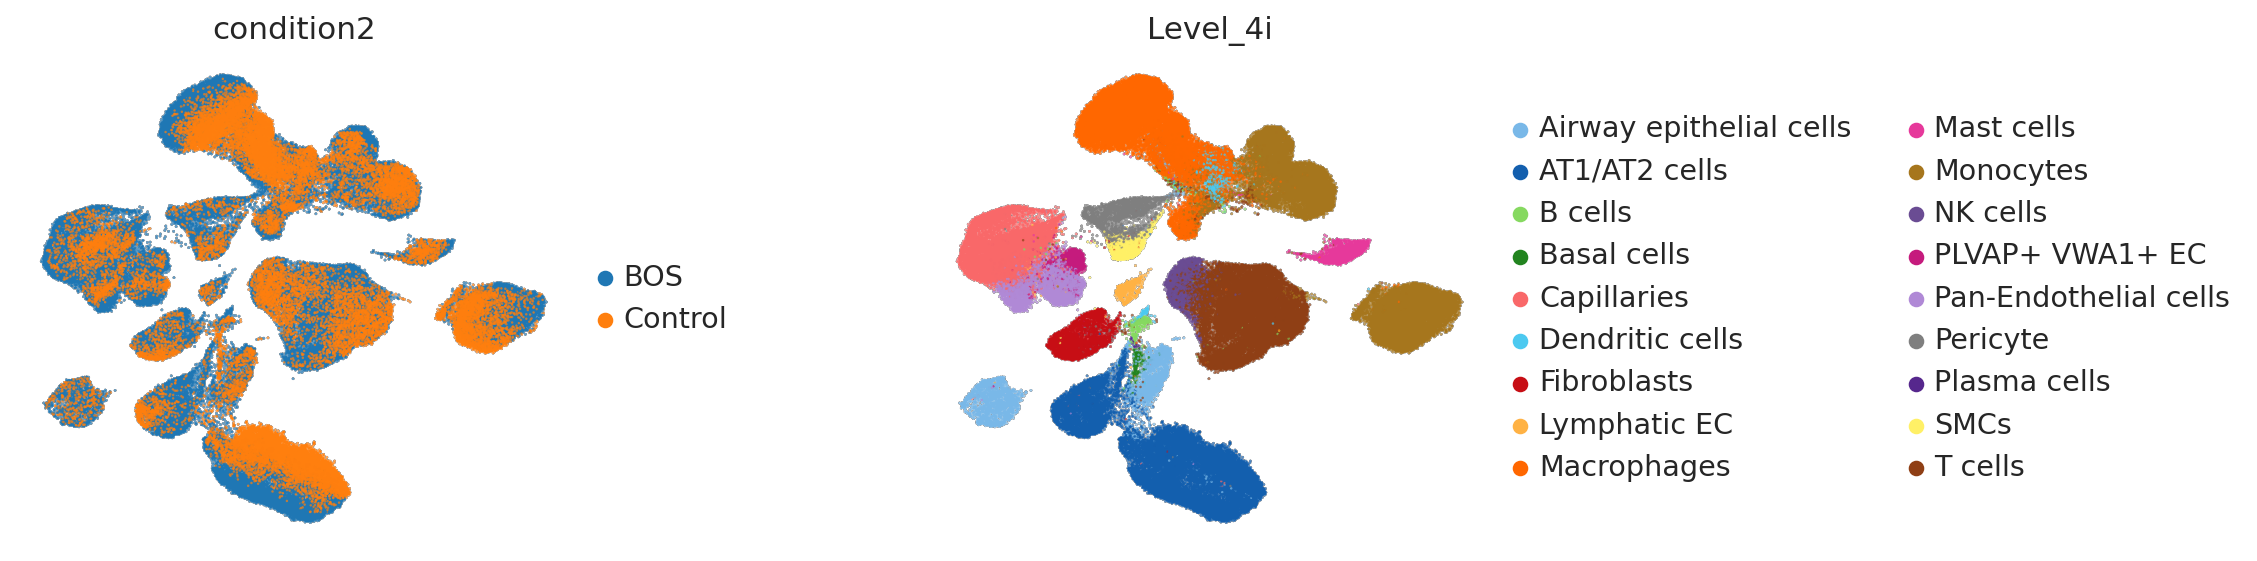

In [13]:
sc.pl.umap(adata, color = ["condition2", "Level_4i"], ncols=2, wspace=0.5, size=5,
          frameon=False,add_outline=True, outline_width=(0.05, 0.01),save=("_BOS_celltype_UMAP.pdf") )

# relative frequency analysis

In [14]:
adata.obs["batch"] = adata.obs["condition"].copy()

In [15]:
xlabel = "condition2"
cell_type_label = "Level_4i"
cols = adata.uns["%s_colors" %cell_type_label]
order = adata.obs[xlabel].cat.categories.values
celltypes = adata.obs["Level_4i"].cat.categories

relFreqs = codes.calc_relFreq(adata, group_by = cell_type_label, xlabel = xlabel,condition=None)
relFreqs.head(5)

,Airway epithelial cells,AT1/AT2 cells,B cells,Basal cells,Capillaries,Dendritic cells,Fibroblasts,Lymphatic EC,Macrophages,Mast cells,Monocytes,NK cells,PLVAP+ VWA1+ EC,Pan-Endothelial cells,Pericyte,Plasma cells,SMCs,T cells,condition2
BOS,0.061386,0.184313,0.003810,0.001097,0.070777,0.009198,0.032367,0.005908,0.121137,0.006485,0.186487,0.018146,0.007409,0.040065,0.030308,0.000135,0.006331,0.214640,BOS
CLAD-BOS,0.021672,0.124498,0.002733,0.001188,0.163328,0.008935,0.032841,0.008175,0.183218,0.025760,0.175756,0.009601,0.028493,0.051995,0.023574,0.000309,0.015541,0.122383,BOS
Control,0.031458,0.211078,0.004204,0.002803,0.047339,0.009486,0.020768,0.003288,0.269160,0.014067,0.202580,0.027398,0.003090,0.024415,0.009594,0.000252,0.008246,0.110776,Control


Saving Figure to /media/synology/Rahel/BOS paper/plots5/_relative_frequency_mellor_et_al.pdf


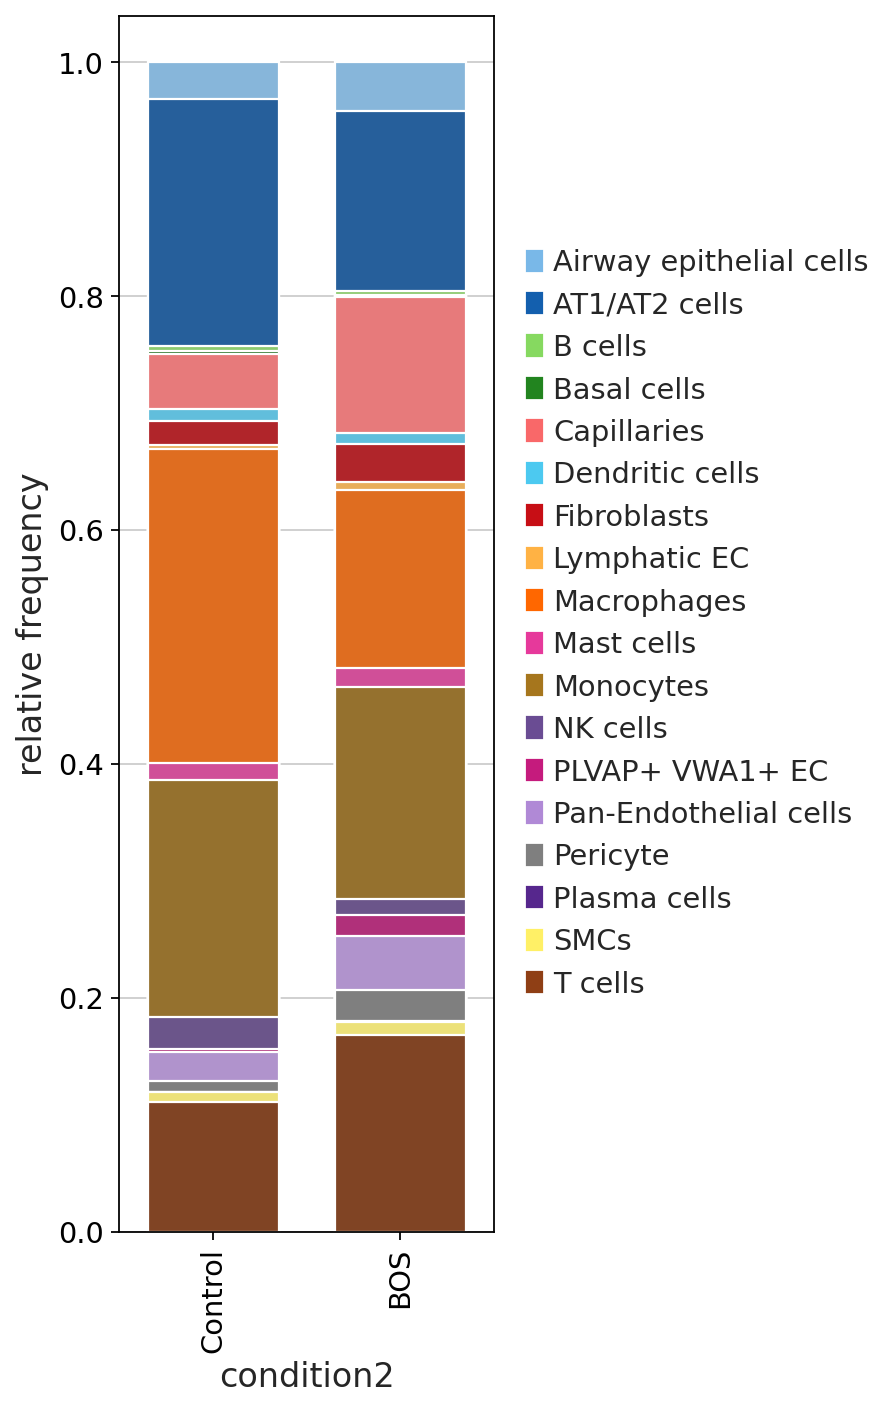

In [16]:
codes.plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (3,10), cols=cols,
                               order= ['Control','BOS'], width = 0.7, save = plot_folder +"_relative_frequency_mellor_et_al.pdf")
#plt.tight_layout()

# Endothelial cell subset

In [17]:
Endothel = adata[adata.obs.Level_4i.isin(['Lymphatic EC','Pan-Endothelial cells','PLVAP+ VWA1+ EC','Capillaries'])].copy()

In [18]:
Endothel

AnnData object with n_obs × n_vars = 21405 × 30081
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'log10genesperUMI', 'percent.mt', 'percent.rb', 'cells', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'pANN_0.25_0.01_479', 'DF', 'predicted.lineage_level1.score', 'predicted.lineage_level1', 'predicted.lineage_level2.score', 'predicted.lineage_level2', 'predicted.celltype_level1.score', 'predicted.celltype_level1', 'predicted.celltype_level2.score', 'predicted.celltype_level2', 'predicted.celltype_level3.score', 'predicted.celltype_level3', 'pANN_0.25_0.03_275', 'pANN_0.25_0.005_288', 'pANN_0.25_0.25_422', 'pANN_0.25_0.04_522', 'pANN_0.25_0.005_270', 'pANN_0.25_0.03_373', 'pANN_0.25_0.04_565', 'integrated_snn_res.0.4', 'integrated_snn_res.0.6', 'integrated_snn_res.0.8', 'integrated_snn_res.1', 'integrated_snn_res.1.4', 'nCount_prediction.score.lineage_level1', 'nFeature_prediction.score.lineage_level1', 'nCount_prediction.score.lineage_level2', 'nFeature_predi

In [19]:
import bbknn
bbknn.bbknn(Endothel, neighbors_within_batch = 5, n_pcs = 50, batch_key = "orig.ident")
sc.tl.umap(Endothel)

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


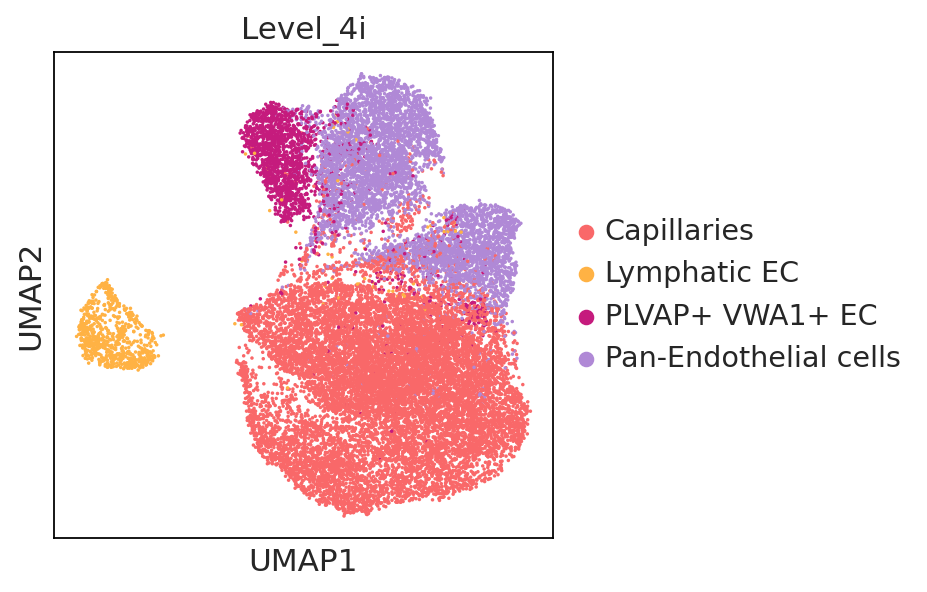

In [20]:
sc.pl.umap(Endothel, color = ["Level_4i"], size = 10,save=("_Umap_endothel_Mellors_et_al.pdf"))

In [21]:
Endothel.obs["batch"] = Endothel.obs["condition"].copy()

In [22]:
xlabel = "condition2"
cell_type_label = "Level_4i"
cols = Endothel.uns["%s_colors" %cell_type_label]
order = Endothel.obs[xlabel].cat.categories.values
celltypes = Endothel.obs["Level_4i"].cat.categories

relFreqs = codes.calc_relFreq(Endothel, group_by = cell_type_label, xlabel = xlabel,condition=None)
relFreqs.head(5)

,Capillaries,Lymphatic EC,PLVAP+ VWA1+ EC,Pan-Endothelial cells,condition2
BOS,0.570056,0.047582,0.059671,0.322691,BOS
CLAD-BOS,0.648152,0.032441,0.113071,0.206337,BOS
Control,0.605886,0.042079,0.039549,0.312486,Control


Saving Figure to /media/synology/Rahel/BOS paper/plots5/_relative_frequency_EC_subset.pdf


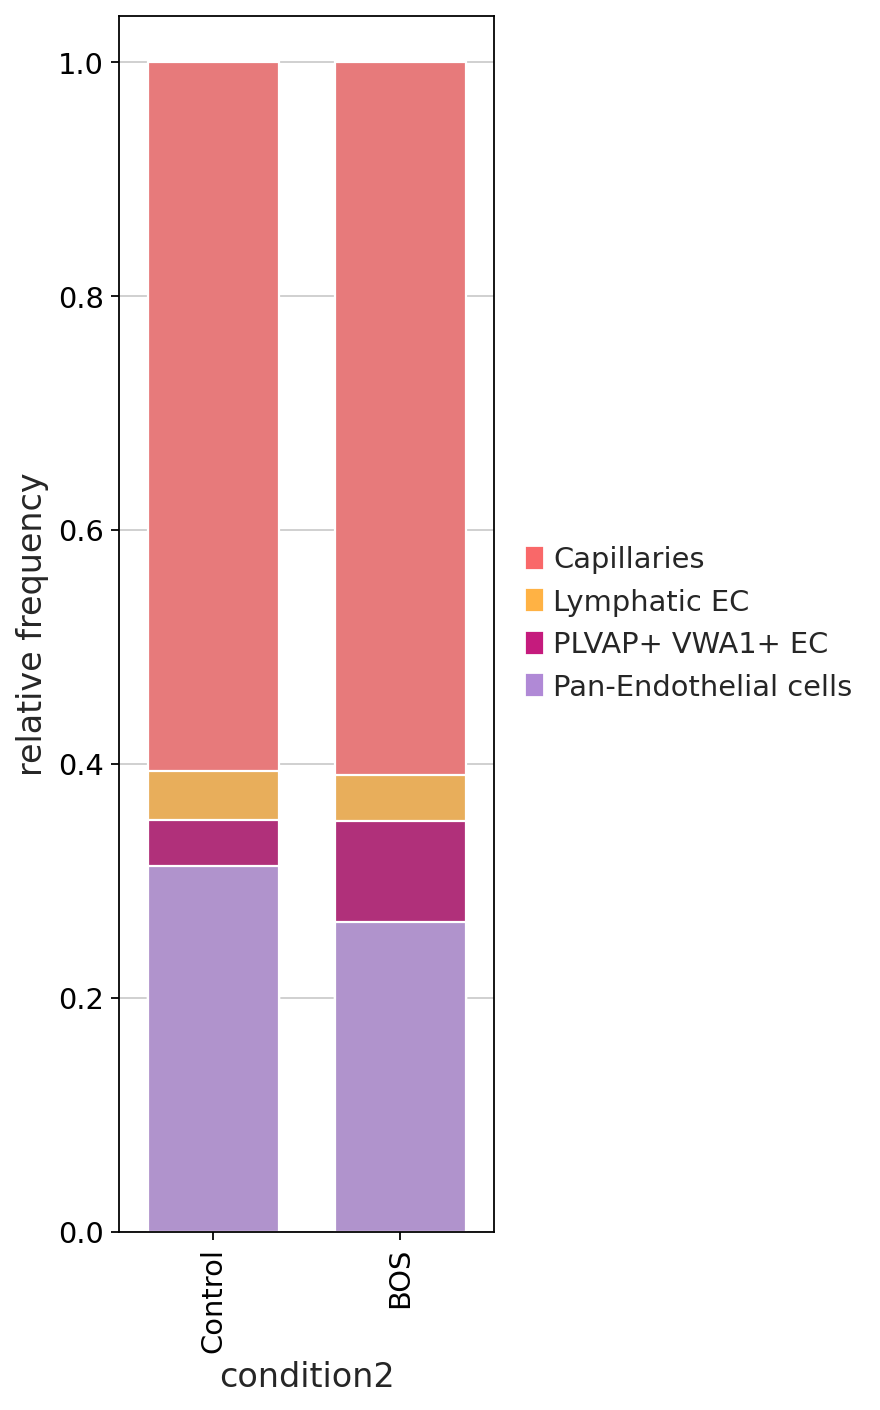

In [23]:
codes.plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (3,10), cols = cols, 
                               margins = (0.02, 0.04), order=["Control","BOS"], width = 0.7, save = plot_folder +"_relative_frequency_EC_subset.pdf")
#plt.tight_layout()